In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
from analysis.analyzer import load_model, ModelAnalyzer, generate_parity_gated_inputs
from trainer.tokenizer import ModularAdditionTokenizer
from trainer.config import ModelConfig

%matplotlib inline

g++ (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [2]:
# Load canonical PT-G model
model_path = PROJECT_ROOT / "outputs/runs/pt-g/ptg_wd0.15_bs1024_ms1234_ss42_sh44_16926075/model.pt"
model = load_model(model_path)

# Set up tokenizer and generate all p^2 inputs
p = 113
tokenizer = ModularAdditionTokenizer(p)
all_inputs, result_labels = generate_parity_gated_inputs(tokenizer)
is_even = (result_labels % 2 == 0)

# Create analyzer (runs forward pass, caches activations)
analyzer = ModelAnalyzer(model, task="ptg")

print(f"Model loaded from: {model_path.name}")
print(f"Inputs shape: {all_inputs.shape}")
print(f"Even: {is_even.sum()}, Odd: {(~is_even).sum()}")

Moving model to device:  cuda
Moving model to device:  cuda
Model loaded from: model.pt
Inputs shape: torch.Size([12769, 6])
Even: 6441, Odd: 6328


In [3]:
# Quick check: attention patterns from position 3 (=) to all positions
cache = analyzer.cache
attn_pattern = cache["blocks.0.attn.hook_pattern"]  # (batch, n_heads, seq_len, seq_len)
eq_pos = 3

# Average attention from = position to each source position, per head
avg_attn = attn_pattern[:, :, eq_pos, :].mean(dim=0).cpu().numpy()  # (n_heads, seq_len)
pos_labels = ["bos", "a", "b", "="]

print("Average attention from '=' to each position:")
print(f"{'Head':<8}" + "".join(f"{l:<10}" for l in pos_labels))
for h in range(avg_attn.shape[0]):
    print(f"  {h:<6}" + "".join(f"{avg_attn[h, i]:<10.4f}" for i in range(4)))

Average attention from '=' to each position:
Head    bos       a         b         =         
  0     0.0035    0.4981    0.4958    0.0027    
  1     0.0082    0.4938    0.4958    0.0022    
  2     0.0041    0.4973    0.4968    0.0018    
  3     0.0081    0.4914    0.4932    0.0074    


## Attention pattern from H1

In [39]:
attnh1 = attn_pattern[:, 1, eq_pos, :].reshape(113, 113, -1)
attnh1.shape

torch.Size([113, 113, 6])

In [47]:
import pandas as pd
from trainer.utils import fourier_transform_2d, get_fourier_basis,get_fourier_basis_names, get_fourier_basis, get_fourier_basis_names

freq_names = get_fourier_basis_names(p)
fourier_basis = get_fourier_basis(p, "cuda")
ft2d_old_correct = fourier_transform_2d(attnh1[:,:, 1], fourier_basis=fourier_basis)


# Display top 20 by power for both
for label, ft in [("A(a)", ft2d_old_correct)]:
    flat = ft.flatten()
    power = torch.abs(flat)
    top20 = power.argsort(descending=True)[:20]
    
    rows = []
    for rank, idx in enumerate(top20):
        i, j = idx.item() // p, idx.item() % p
        rows.append({
            "Rank": rank + 1,
            "Freq (a)": freq_names[i],
            "Freq (b)": freq_names[j],
            "Coefficient": flat[idx].item(),
            "Power": power[idx].item(),
        })
    
    print(f"\n{'='*70}")
    print(f"  {label} — 2D Fourier of correct-token logits")
    print(f"{'='*70}")
    display(pd.DataFrame(rows).set_index("Rank"))



  A(a) — 2D Fourier of correct-token logits


,Freq (a),Freq (b),Coefficient,Power
Rank,,,,
1,Const,Const,55.804771,55.804771
2,sin 56,Const,18.429159,18.429159
3,Const,sin 56,-17.852003,17.852003
4,cos 56,Const,-15.903532,15.903532
5,Const,cos 56,15.402346,15.402346
6,sin 1,sin 56,2.909826,2.909826
7,sin 56,sin 1,-2.819129,2.819129
8,sin 1,cos 56,-2.520333,2.520333
9,cos 56,sin 1,2.438977,2.438977


In [26]:
ft2d_old_correct = fourier_transform_2d(attnh1[:,:, 2], fourier_basis=fourier_basis)


# Display top 20 by power for both
for label, ft in [("A(b)", ft2d_old_correct)]:
    flat = ft.flatten()
    power = torch.abs(flat)
    top20 = power.argsort(descending=True)[:10]
    
    rows = []
    for rank, idx in enumerate(top20):
        i, j = idx.item() // p, idx.item() % p
        rows.append({
            "Rank": rank + 1,
            "Freq (a)": freq_names[i],
            "Freq (b)": freq_names[j],
            "Coefficient": flat[idx].item(),
            "Power": power[idx].item(),
            "Power (norm)": power[idx].item() / power[top20[0]].item(),
        })
    
    print(f"\n{'='*70}")
    print(f"  {label} — 2D Fourier of correct-token logits")
    print(f"{'='*70}")
    display(pd.DataFrame(rows).set_index("Rank"))



  A(b) — 2D Fourier of correct-token logits


,Freq (a),Freq (b),Coefficient,Power,Power (norm)
Rank,,,,,
1,Const,Const,56.021946,56.021946,1.000000
2,Const,sin 56,18.428246,18.428246,0.328947
3,sin 56,Const,-17.854145,17.854145,0.318699
4,Const,cos 56,-15.903566,15.903566,0.283881
5,cos 56,Const,15.403407,15.403407,0.274953
6,sin 56,sin 1,2.913543,2.913543,0.052007
7,sin 1,sin 56,-2.816220,2.816220,0.050270
8,cos 56,sin 1,-2.522811,2.522811,0.045033
9,sin 1,cos 56,2.437195,2.437195,0.043504


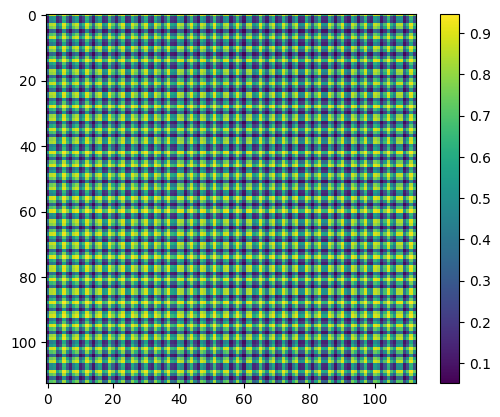

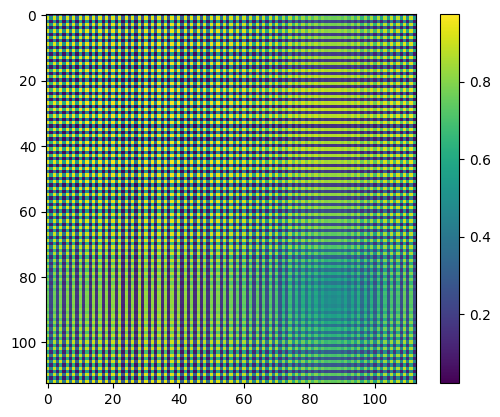

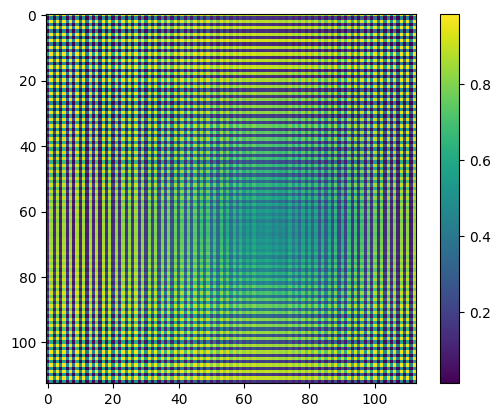

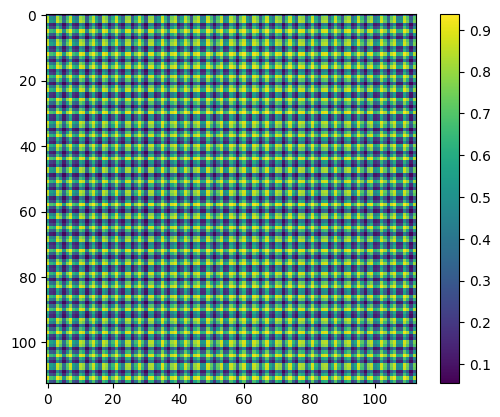

In [32]:
for head_idx in range(4):
    attn_head = attn_pattern[:, head_idx, eq_pos, :].reshape(113, 113, -1)
    plt.imshow(attn_head[:,:, 1].cpu().numpy())
    plt.colorbar()
    plt.show()

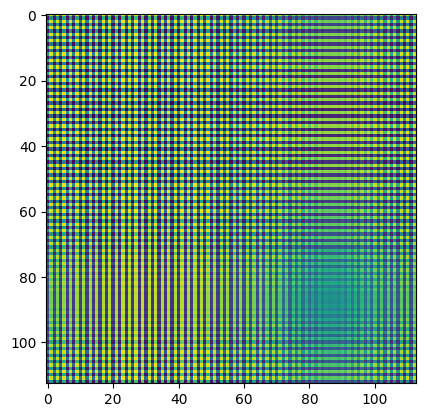

In [31]:
plt.imshow(attnh1[:,:, 2].cpu().numpy())

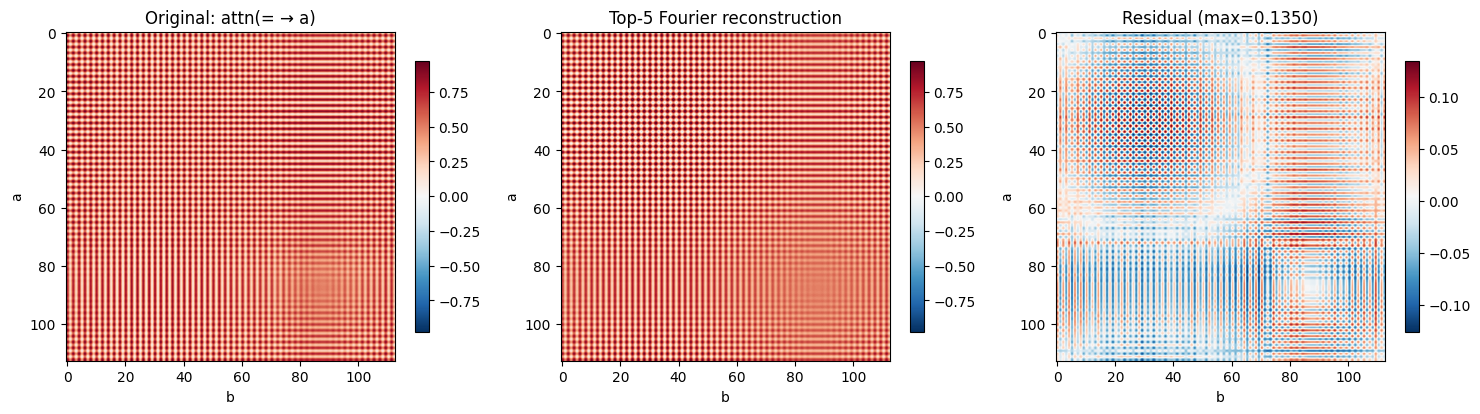

Original norm:  65.5802
Residual norm:  6.1730
Fraction of variance explained: 0.991140


In [45]:
# Reconstruct from top-k Fourier coefficients and plot residual
arr = attnh1[:, :, 1].cpu()  # attention to position a, shape (p, p)
coeffs = fourier_transform_2d(arr, fourier_basis=fourier_basis.cpu())  # (p, p)

# Zero out everything except top-k by absolute value
k = 5
flat = coeffs.flatten()
topk_idx = torch.abs(flat).argsort(descending=True)[:k]
coeffs_topk = torch.zeros_like(coeffs)
for idx in topk_idx:
    i, j = idx.item() // p, idx.item() % p
    coeffs_topk[i, j] = coeffs[i, j]

# Reconstruct: arr_approx = F^T @ coeffs_topk @ F
F = fourier_basis.cpu()
arr_topk = F.T @ coeffs_topk @ F

residual = arr - arr_topk

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = arr.abs().max().item()

im0 = axes[0].imshow(arr.numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title("Original: attn(= → a)")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(arr_topk.numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title(f"Top-{k} Fourier reconstruction")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(residual.numpy(), cmap='RdBu_r')
axes[2].set_title(f"Residual (max={residual.abs().max():.4f})")
plt.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xlabel("b")
    ax.set_ylabel("a")

plt.tight_layout()
plt.show()

# Print reconstruction quality
print(f"Original norm:  {arr.norm():.4f}")
print(f"Residual norm:  {residual.norm():.4f}")
print(f"Fraction of variance explained: {1 - (residual.norm()**2 / arr.norm()**2):.6f}")

### Top-5 Fourier reconstruction of $\alpha_1(= \to a)$

The 2D Fourier decomposition gives $f(a,b) = \sum_{i,j} c_{ij} \varphi_i(a) \varphi_j(b)$, where the orthonormal basis functions are:

$$\varphi_0(n) = \frac{1}{\sqrt{p}}, \quad \varphi_{\cos k}(n) = \sqrt{\frac{2}{p}}\cos\left(\frac{2\pi k n}{p}\right), \quad \varphi_{\sin k}(n) = \sqrt{\frac{2}{p}}\sin\left(\frac{2\pi k n}{p}\right)$$

Substituting the top-5 coefficients and absorbing the normalizations ($1/p$ for const x const, $\sqrt{2}/p$ for mixed):

$$\alpha_1(= \to a) \approx \underbrace{0.494}_{\text{const}} + \underbrace{0.231\sin\frac{112\pi a}{113} - 0.199\cos\frac{112\pi a}{113}}_{\text{parity of } a} + \underbrace{-0.224\sin\frac{112\pi b}{113} + 0.193\cos\frac{112\pi b}{113}}_{\text{parity of } b}$$

where $\frac{2\pi \cdot 56}{113} = \frac{112\pi}{113} \approx \pi$, so $\cos\frac{112\pi n}{113} \approx (-1)^n$ (the parity signal).

**Key observation:** The attention weight is **additively separable** in parity(a) and parity(b) — no multiplicative interaction. This is consistent with attention being a linear operation over values.

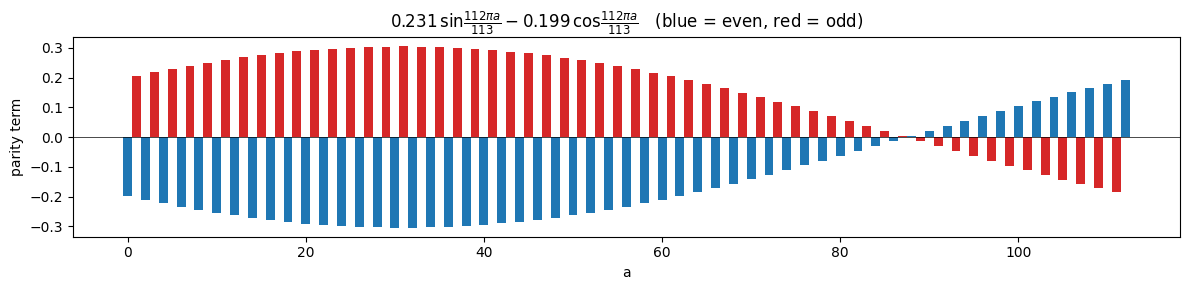

In [46]:
# Plot the parity-of-a term: 0.231*sin(112*pi*a/113) - 0.199*cos(112*pi*a/113)
a = np.arange(p)
parity_a = 0.231 * np.sin(112 * np.pi * a / 113) - 0.199 * np.cos(112 * np.pi * a / 113)

fig, ax = plt.subplots(figsize=(12, 3))
colors = ['tab:blue' if x % 2 == 0 else 'tab:red' for x in a]
ax.bar(a, parity_a, color=colors, width=1.0, edgecolor='none')
ax.set_xlabel("a")
ax.set_ylabel("parity term")
ax.set_title(r"$0.231\,\sin\!\frac{112\pi a}{113} - 0.199\,\cos\!\frac{112\pi a}{113}$   (blue = even, red = odd)")
ax.axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

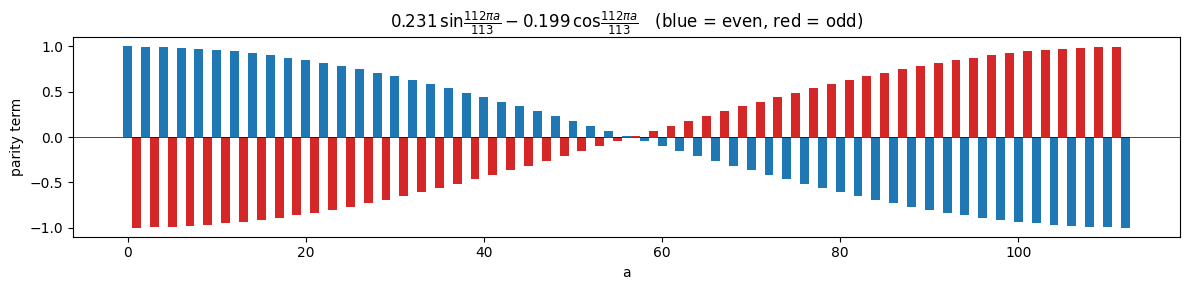

In [48]:
# Plot the parity-of-a term: 0.231*sin(112*pi*a/113) - 0.199*cos(112*pi*a/113)
a = np.arange(p)
parity_a =  np.cos(112 * np.pi * a / 113)

fig, ax = plt.subplots(figsize=(12, 3))
colors = ['tab:blue' if x % 2 == 0 else 'tab:red' for x in a]
ax.bar(a, parity_a, color=colors, width=1.0, edgecolor='none')
ax.set_xlabel("a")
ax.set_ylabel("parity term")
ax.set_title(r"$0.231\,\sin\!\frac{112\pi a}{113} - 0.199\,\cos\!\frac{112\pi a}{113}$   (blue = even, red = odd)")
ax.axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

$$\cos!\left(\frac{2\pi \cdot 56 \cdot n}{113}\right) = \cos!\left(\pi n - \frac{\pi n}{113}\right) = (-1)^n \cdot \cos!\left(\frac{\pi    
  n}{113}\right)$$

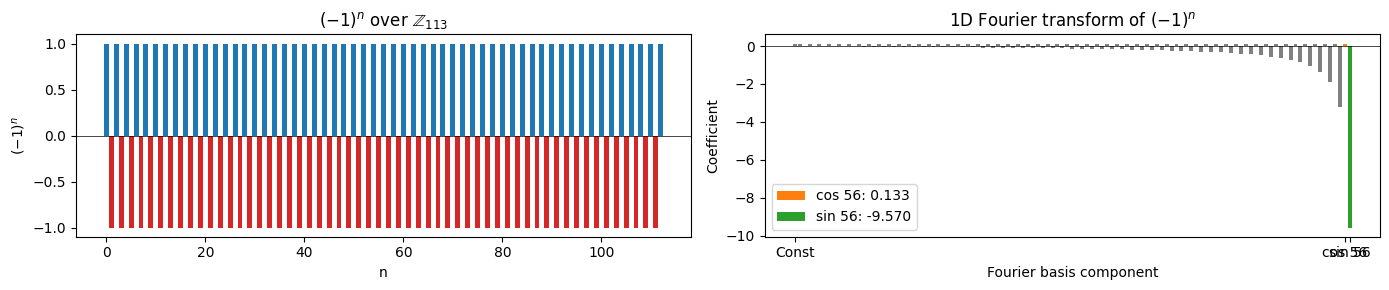

In [49]:
from trainer.utils import fourier_transform_1d

# (-1)^n over Z_113
n = np.arange(p)
parity_signal = (-1.0) ** n

# 1D Fourier transform
ft1d = fourier_transform_1d(parity_signal, fourier_basis=fourier_basis.cpu())

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# Left: the signal (-1)^n
colors = ['tab:blue' if x % 2 == 0 else 'tab:red' for x in n]
axes[0].bar(n, parity_signal, color=colors, width=1.0, edgecolor='none')
axes[0].set_xlabel("n")
axes[0].set_ylabel("$(-1)^n$")
axes[0].set_title("$(-1)^n$ over $\\mathbb{Z}_{113}$")
axes[0].axhline(0, color='k', lw=0.5)

# Right: Fourier coefficients
axes[1].bar(range(len(freq_names)), ft1d, width=0.8, color='gray')
# Highlight cos 56 and sin 56
cos56_idx = freq_names.index('cos 56')
sin56_idx = freq_names.index('sin 56')
axes[1].bar(cos56_idx, ft1d[cos56_idx], color='tab:orange', width=0.8, label=f'cos 56: {ft1d[cos56_idx]:.3f}')
axes[1].bar(sin56_idx, ft1d[sin56_idx], color='tab:green', width=0.8, label=f'sin 56: {ft1d[sin56_idx]:.3f}')
axes[1].set_xlabel("Fourier basis component")
axes[1].set_ylabel("Coefficient")
axes[1].set_title("1D Fourier transform of $(-1)^n$")
axes[1].set_xticks([0, cos56_idx, sin56_idx])
axes[1].set_xticklabels(['Const', 'cos 56', 'sin 56'])
axes[1].legend()
axes[1].axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

In [56]:
ans = np.round(ft1d,2)

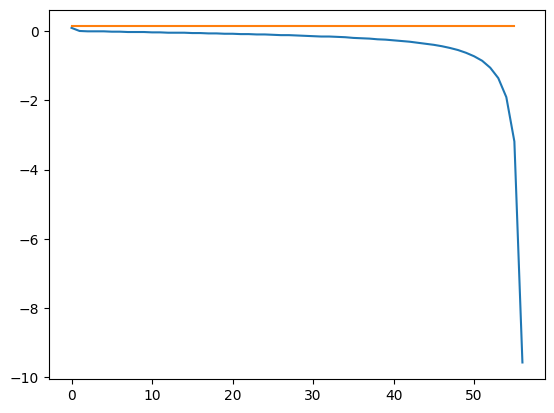

In [58]:
plt.plot(ans[::2])
plt.plot(ans[1::2])